In [10]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import cv2
from ultralytics import YOLO

In [11]:
# Install once if needed
# !pip install ultralytics opencv-python

In [12]:
# -----------------------------
# CONFIG
# -----------------------------
# Top-level folder that contains all your subfolders
INPUT_DIR = Path(r"C:\Projects\PoseEstimation\pose_images_backup")

# Output folder
OUTPUT_DIR = Path(r"C:\Projects\PoseEstimation\auto_pose_output")

MODEL_NAME = "yolov8n-pose.pt"
CONF_THRESHOLD = 0.25

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

KEYPOINT_NAMES = [
    "nose",
    "left_eye",
    "right_eye",
    "left_ear",
    "right_ear",
    "left_shoulder",
    "right_shoulder",
    "left_elbow",
    "right_elbow",
    "left_wrist",
    "right_wrist",
    "left_hip",
    "right_hip",
    "left_knee",
    "right_knee",
    "left_ankle",
    "right_ankle",
]

In [13]:
def find_images(folder: Path) -> list[Path]:
    # rglob("*") searches recursively through all subfolders
    return sorted(
        [p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
    )


def ensure_dirs() -> tuple[Path, Path]:
    annotated_dir = OUTPUT_DIR / "annotated_images"
    json_dir = OUTPUT_DIR / "json_labels"
    annotated_dir.mkdir(parents=True, exist_ok=True)
    json_dir.mkdir(parents=True, exist_ok=True)
    return annotated_dir, json_dir


def safe_output_name(image_path: Path, root_dir: Path) -> str:
    """
    Make output filenames unique by including subfolder names.
    Example:
    e9ff15a_current\\img1.jpg -> e9ff15a_current__img1.jpg
    """
    relative_path = image_path.relative_to(root_dir)
    parts = list(relative_path.parts)
    return "__".join(parts)


def result_to_dict(result: Any, image_path: Path) -> dict[str, Any]:
    output: dict[str, Any] = {
        "image_path": str(image_path),
        "image_name": image_path.name,
        "detections": [],
    }

    boxes = result.boxes
    keypoints = result.keypoints

    if boxes is None or len(boxes) == 0:
        return output

    xyxy = boxes.xyxy.cpu().numpy()
    confs = boxes.conf.cpu().numpy() if boxes.conf is not None else []
    classes = boxes.cls.cpu().numpy() if boxes.cls is not None else []

    kp_xy = keypoints.xy.cpu().numpy() if keypoints is not None else None
    kp_conf = None
    if keypoints is not None and getattr(keypoints, "conf", None) is not None:
        kp_conf = keypoints.conf.cpu().numpy()

    for i in range(len(boxes)):
        det: dict[str, Any] = {
            "bbox_xyxy": [float(v) for v in xyxy[i]],
            "box_confidence": float(confs[i]) if len(confs) > i else None,
            "class_id": int(classes[i]) if len(classes) > i else None,
            "class_name": "person",
            "keypoints": {},
        }

        if kp_xy is not None and len(kp_xy) > i:
            for j, kp_name in enumerate(KEYPOINT_NAMES):
                x, y = kp_xy[i][j]
                conf_val = float(kp_conf[i][j]) if kp_conf is not None else None

                det["keypoints"][kp_name] = {
                    "x": float(x),
                    "y": float(y),
                    "confidence": conf_val,
                }

        output["detections"].append(det)

    return output

In [14]:
if not INPUT_DIR.exists():
    raise FileNotFoundError(f"Input folder not found: {INPUT_DIR}")

annotated_dir, json_dir = ensure_dirs()
image_paths = find_images(INPUT_DIR)

if not image_paths:
    raise ValueError(f"No images found in: {INPUT_DIR}")

print(f"Found {len(image_paths)} images total across all subfolders.")
print(f"Loading model: {MODEL_NAME}")

model = YOLO(MODEL_NAME)

# Optional: preview a few found files
for p in image_paths[:10]:
    print(p)

Found 701 images total across all subfolders.
Loading model: yolov8n-pose.pt
C:\Projects\PoseEstimation\pose_images_backup\9e965ec_initial\img_0.jpg
C:\Projects\PoseEstimation\pose_images_backup\9e965ec_initial\img_1.jpg
C:\Projects\PoseEstimation\pose_images_backup\9e965ec_initial\img_2.jpg
C:\Projects\PoseEstimation\pose_images_backup\9e965ec_initial\img_3.jpg
C:\Projects\PoseEstimation\pose_images_backup\9e965ec_initial\img_4.jpg
C:\Projects\PoseEstimation\pose_images_backup\9e965ec_initial\img_5.jpg
C:\Projects\PoseEstimation\pose_images_backup\c3da00c_added_photos\img_0.jpg
C:\Projects\PoseEstimation\pose_images_backup\c3da00c_added_photos\img_1.jpg
C:\Projects\PoseEstimation\pose_images_backup\c3da00c_added_photos\img_10.jpg
C:\Projects\PoseEstimation\pose_images_backup\c3da00c_added_photos\img_100.jpg


In [15]:
for idx, image_path in enumerate(image_paths, start=1):
    print(f"[{idx}/{len(image_paths)}] Processing: {image_path}")

    results = model.predict(
        source=str(image_path),
        conf=CONF_THRESHOLD,
        save=False,
        verbose=False,
    )

    if not results:
        print(f"  No result returned for {image_path.name}")
        continue

    result = results[0]

    # Create unique output filename based on subfolder path
    output_name = safe_output_name(image_path, INPUT_DIR)

    # Save annotated image
    plotted = result.plot()
    annotated_path = annotated_dir / output_name
    cv2.imwrite(str(annotated_path), plotted)

    # Save JSON labels
    result_dict = result_to_dict(result, image_path)
    json_filename = Path(output_name).with_suffix(".json").name
    json_path = json_dir / json_filename
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(result_dict, f, indent=2)

print("\nDone.")
print(f"Annotated images saved to: {annotated_dir}")
print(f"JSON labels saved to: {json_dir}")

[1/701] Processing: C:\Projects\PoseEstimation\pose_images_backup\9e965ec_initial\img_0.jpg
[2/701] Processing: C:\Projects\PoseEstimation\pose_images_backup\9e965ec_initial\img_1.jpg
[3/701] Processing: C:\Projects\PoseEstimation\pose_images_backup\9e965ec_initial\img_2.jpg
[4/701] Processing: C:\Projects\PoseEstimation\pose_images_backup\9e965ec_initial\img_3.jpg
[5/701] Processing: C:\Projects\PoseEstimation\pose_images_backup\9e965ec_initial\img_4.jpg
[6/701] Processing: C:\Projects\PoseEstimation\pose_images_backup\9e965ec_initial\img_5.jpg
[7/701] Processing: C:\Projects\PoseEstimation\pose_images_backup\c3da00c_added_photos\img_0.jpg
[8/701] Processing: C:\Projects\PoseEstimation\pose_images_backup\c3da00c_added_photos\img_1.jpg
[9/701] Processing: C:\Projects\PoseEstimation\pose_images_backup\c3da00c_added_photos\img_10.jpg
[10/701] Processing: C:\Projects\PoseEstimation\pose_images_backup\c3da00c_added_photos\img_100.jpg
[11/701] Processing: C:\Projects\PoseEstimation\pose_ima

9e965ec_initial__img_0.jpg


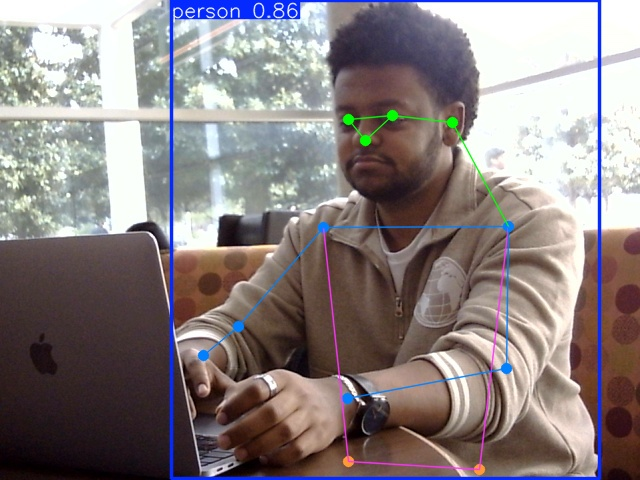

In [16]:
from IPython.display import Image, display

annotated_files = sorted((OUTPUT_DIR / "annotated_images").glob("*"))
if annotated_files:
    print(annotated_files[0].name)
    display(Image(filename=str(annotated_files[0])))
else:
    print("No annotated images found yet.")